# 1-D TEM Inversion Notebook


In the previous notebook (`pytem_fwd.ipynb`), pyTEM's forward model was validated against analytical half-space solutions and published benchmarks. That work established **accuracy**: the simulated $\mathrm{d}B/\mathrm{d}t$ responses match independent references across the full time range.

Accuracy alone is not sufficient for inversion. Each Gauss-Newton iteration constructs the Jacobian $\mathbf{J}$ by finite differences, which requires one baseline forward evaluation plus one perturbed evaluation per model layer. For a 28-layer mesh that is 29 forward calls just to build $\mathbf{J}$. The regularisation line search adds one call per trial value of $\alpha$. Across 15–30 iterations a typical inversion run involves **more than 500 forward evaluations**. A ×10 speed-up in the forward model therefore reduces a 10-minute inversion to under one minute.

Section 1 below quantifies the computation time for all available filter configurations and computational backends, so the right combination can be chosen for the hardware at hand.

## 1. Forward Model Performance

The 1-D TEM forward model evaluates the layered-earth electromagnetic response by convolving the frequency-domain kernel with **Digital Linear Filters (DLF)** that approximate the Hankel and Fourier transforms. Two parameters control the accuracy–speed trade-off:

| Parameter | Available options | Effect |
|-----------|------------------|--------|
| Hankel filter length | `key_101` (101 pts), `key_201` (201 pts) | Longer filters improve accuracy at the cost of more kernel evaluations |
| Fourier filter length | `key_81` (81 pts), `key_101` (101 pts) | Same trade-off for the cosine/sine transform |

The Laplace-to-time step can also be done with the **Euler–Stehfest** accelerated series instead of a DLF, controlled by the order (8, 11, 15, or 19 terms).

Beyond filter choice, the inner convolution is embarrassingly parallel and can be accelerated with:
- **Numba**: JIT-compiles the loop to native CPU machine code (requires the `numba` package).
- **CUDA**: offloads the computation to an NVIDIA GPU (requires `cupy`).

Sections 1.1 and 1.2 time all available combinations on this machine.

In [4]:
import sys
import time
import importlib

import numpy as np
import matplotlib.pyplot as plt

sys.path.insert(0, r'C:\Users\pamcl\OneDrive - Danmarks Tekniske Universitet\Dokumenter\Projects\Python\pyTEM')

import pytem
importlib.reload(pytem.recursion)
importlib.reload(pytem)

from pytem import (
    tem_forward_circle,
    tem_forward_circle_offset,
    tem_forward_square,
    tem_forward_square_offset,
    dbdt_to_apprho,
    MU0,
    HAS_NUMBA,
    HAS_CUDA,
    HANKEL_FILTERS,
    FOURIER_FILTERS,
    EULER_PARAMS,
)

print(f"Numba: {HAS_NUMBA}, CUDA: {HAS_CUDA}")


Numba: True, CUDA: True


### 1.1 Digital Filter Configuration

The DLF approach approximates the two integral transforms in the forward model:

1. **Hankel transform** — converts the radial wavenumber kernel to the spatial domain. pyTEM provides a 101-point and a 201-point version of the Key (2009) filter.
2. **Fourier transform** — converts the frequency-domain result to the time domain. pyTEM provides an 81-point (Key 2009) and a 101-point (Key 2012) sine/cosine filter.

Longer filters converge more accurately for slowly varying kernels at the cost of proportionally more multiplications per gate. For most geophysical TEM applications the 101-point versions are indistinguishable from the 201-point versions in the time range of interest.

As an alternative, the **Euler–Stehfest** accelerated series evaluates the inverse Laplace transform directly without a Fourier filter. Higher orders give better accuracy but require more kernel evaluations.

The cell below measures median forward-call time for each combination using only the NumPy backend, so that only filter length affects the result.

In [ ]:
# ============================================================================
# 1.1  Filter / transform timing and accuracy  (NumPy backend)
# ============================================================================

# Benchmark model: 6 layers, 50 m loop
_thick_bm = np.array([5., 5., 10., 10., 15.])
_rho_bm   = np.array([100., 50., 200., 30., 100., 80.])
_a_bm     = np.sqrt(50.**2 / np.pi)   # equivalent circle radius [m]
_times_bm = np.logspace(-5, -2, 15)   # 15 log-spaced gates (benchmark only)
_N_REPS   = 3


def bench(fn, n=_N_REPS):
    """Median wall-clock time [s] over *n* repetitions."""
    t_list = []
    for _ in range(n):
        t0 = time.perf_counter()
        fn()
        t_list.append(time.perf_counter() - t0)
    return float(np.median(t_list))


# Reference response: longest available DLF (201-pt Hankel, 101-pt Fourier)
_ref_response = tem_forward_circle(
    thicknesses=_thick_bm, resistivities=_rho_bm,
    tx_radius=_a_bm, times=_times_bm,
    use_numba=False, use_cuda=False,
    transform='dlf', hankel_filter='key_201', fourier_filter='key_101',
)

filter_results   = {}   # median time [s]
accuracy_results = {}   # max relative error vs reference

print(f"{'Config':40s}  {'Time [ms]':>10s}  {'Max rel. err':>14s}")
print("-" * 68)

print("DLF (Hankel × Fourier filter):")
for hf in HANKEL_FILTERS:
    for ff in FOURIER_FILTERS:
        label = f"DLF  H:{hf}  F:{ff}"
        resp = tem_forward_circle(
            thicknesses=_thick_bm, resistivities=_rho_bm,
            tx_radius=_a_bm, times=_times_bm,
            use_numba=False, use_cuda=False,
            transform='dlf', hankel_filter=hf, fourier_filter=ff,
        )
        err = float(np.max(np.abs(resp - _ref_response) / np.abs(_ref_response)))
        t = bench(lambda hf=hf, ff=ff: tem_forward_circle(
            thicknesses=_thick_bm, resistivities=_rho_bm,
            tx_radius=_a_bm, times=_times_bm,
            use_numba=False, use_cuda=False,
            transform='dlf', hankel_filter=hf, fourier_filter=ff,
        ))
        filter_results[label]   = t
        accuracy_results[label] = err
        ref_marker = "  ← reference" if (hf == 'key_201' and ff == 'key_101') else ""
        print(f"  {label:38s}  {t * 1000:10.2f}  {err:14.2e}{ref_marker}")

print("\nEuler–Stehfest (varying order):")
for order in EULER_PARAMS:
    label = f"Euler  order={order}"
    resp = tem_forward_circle(
        thicknesses=_thick_bm, resistivities=_rho_bm,
        tx_radius=_a_bm, times=_times_bm,
        use_numba=False, use_cuda=False,
        transform='euler', euler_order=order,
    )
    err = float(np.max(np.abs(resp - _ref_response) / np.abs(_ref_response)))
    t = bench(lambda o=order: tem_forward_circle(
        thicknesses=_thick_bm, resistivities=_rho_bm,
            tx_radius=_a_bm, times=_times_bm,
        use_numba=False, use_cuda=False,
        transform='euler', euler_order=o,
    ))
    filter_results[label]   = t
    accuracy_results[label] = err
    print(f"  {label:38s}  {t * 1000:10.2f}  {err:14.2e}")


Config                                     Time [ms]    Max rel. err
--------------------------------------------------------------------
DLF (Hankel × Fourier filter):
  DLF  H:key_201  F:key_81                    489.42        2.02e-04
  DLF  H:key_201  F:key_101                   546.26        0.00e+00  ← reference
  DLF  H:key_101  F:key_81                    441.11        2.02e-04
  DLF  H:key_101  F:key_101                   464.73        1.60e-07

Euler–Stehfest (varying order):
  Euler  order=8                              117.12        2.38e-03
  Euler  order=11                             143.00        1.75e-04
  Euler  order=15                             242.35        1.83e-04
  Euler  order=19                             203.36        1.85e-04


### 1.2 Computational Backends and Loop Geometry

Filter length is only one dimension of performance. Two further levers are available:

| Backend | How it works | Requirement |
|---------|-------------|-------------|
| **NumPy** | Pure Python/NumPy vectorised loops | Always available |
| **Numba** | JIT-compiles the inner filter loop to native CPU machine code | `pip install numba` |
| **CUDA** | Offloads the convolution to an NVIDIA GPU | NVIDIA GPU + `pip install cupy` |

Loop **geometry** also matters. A square transmitter loop requires integrating along four sides. Setting `use_symmetry=True` exploits the 4-fold symmetry of the square to reduce this to a single side (4× speed-up). The benchmark below covers:

- Circle (central receiver)
- Square — full integration
- Square — symmetric integration
- Circle (offset receiver)
- Square — full (offset receiver)

all timed against every available backend.

In [ ]:
# ============================================================================
# 1.4  Geometry × backend timing: Circle, Square-Full, Square-Sym
# ============================================================================
# Filter / transform fixed to Euler order 11 with key_101 Hankel filter.
# bench() and the benchmark model (_thick_bm, _rho_bm, _a_bm, _times_bm)
# are defined in section 1.1 above.
# Single-rep timing (n=1) — square integration is slow, rough comparison is enough.

_L_bm  = np.sqrt(np.pi) * _a_bm   # square loop side [m] (same area as circle)
_rx_bm = 10.0                       # offset receiver distance [m]
_cfg   = dict(transform='euler', hankel_filter='key_101', euler_order=11)

results = {}

# Circle (central)
results['Circle (np)'] = bench(lambda: tem_forward_circle(
    _thick_bm, _rho_bm, _a_bm, _times_bm, use_numba=False, use_cuda=False, **_cfg), n=1)
if HAS_NUMBA:
    results['Circle (nb)'] = bench(lambda: tem_forward_circle(
        _thick_bm, _rho_bm, _a_bm, _times_bm, use_numba=True, use_cuda=False, **_cfg), n=1)
if HAS_CUDA:
    results['Circle (cuda)'] = bench(lambda: tem_forward_circle(
        _thick_bm, _rho_bm, _a_bm, _times_bm, use_numba=False, use_cuda=True, **_cfg), n=1)

# Square - Full
results['Square - Full (np)'] = bench(lambda: tem_forward_square(
    _thick_bm, _rho_bm, _L_bm, _times_bm, use_numba=False, use_cuda=False, use_symmetry=False, **_cfg), n=1)
if HAS_NUMBA:
    results['Square - Full (nb)'] = bench(lambda: tem_forward_square(
        _thick_bm, _rho_bm, _L_bm, _times_bm, use_numba=True, use_cuda=False, use_symmetry=False, **_cfg), n=1)
if HAS_CUDA:
    results['Square - Full (cuda)'] = bench(lambda: tem_forward_square(
        _thick_bm, _rho_bm, _L_bm, _times_bm, use_numba=False, use_cuda=True, use_symmetry=False, **_cfg), n=1)

# Square - Sym
results['Square - Sym (np)'] = bench(lambda: tem_forward_square(
    _thick_bm, _rho_bm, _L_bm, _times_bm, use_numba=False, use_cuda=False, use_symmetry=True, **_cfg), n=1)
if HAS_NUMBA:
    results['Square - Sym (nb)'] = bench(lambda: tem_forward_square(
        _thick_bm, _rho_bm, _L_bm, _times_bm, use_numba=True, use_cuda=False, use_symmetry=True, **_cfg), n=1)
if HAS_CUDA:
    results['Square - Sym (cuda)'] = bench(lambda: tem_forward_square(
        _thick_bm, _rho_bm, _L_bm, _times_bm, use_numba=False, use_cuda=True, use_symmetry=True, **_cfg), n=1)

# --- Offset timing ---
results_offset = {}

results_offset['Circle (np)'] = bench(lambda: tem_forward_circle_offset(
    _thick_bm, _rho_bm, _a_bm, _rx_bm, _times_bm, use_numba=False, use_cuda=False, **_cfg), n=1)
if HAS_NUMBA:
    results_offset['Circle (nb)'] = bench(lambda: tem_forward_circle_offset(
        _thick_bm, _rho_bm, _a_bm, _rx_bm, _times_bm, use_numba=True, use_cuda=False, **_cfg), n=1)
if HAS_CUDA:
    results_offset['Circle (cuda)'] = bench(lambda: tem_forward_circle_offset(
        _thick_bm, _rho_bm, _a_bm, _rx_bm, _times_bm, use_numba=False, use_cuda=True, **_cfg), n=1)

results_offset['Square - Full (np)'] = bench(lambda: tem_forward_square_offset(
    _thick_bm, _rho_bm, _L_bm, _rx_bm, 0.0, _times_bm, use_numba=False, use_cuda=False, **_cfg), n=1)
if HAS_NUMBA:
    results_offset['Square - Full (nb)'] = bench(lambda: tem_forward_square_offset(
        _thick_bm, _rho_bm, _L_bm, _rx_bm, 0.0, _times_bm, use_numba=True, use_cuda=False, **_cfg), n=1)
if HAS_CUDA:
    results_offset['Square - Full (cuda)'] = bench(lambda: tem_forward_square_offset(
        _thick_bm, _rho_bm, _L_bm, _rx_bm, 0.0, _times_bm, use_numba=False, use_cuda=True, **_cfg), n=1)

print("Central-loop timings:")
for k, v in results.items():
    print(f"  {k:26s}: {v:.4f} s")
print(f"\nOffset-loop timings (r = {_rx_bm:g} m):")
for k, v in results_offset.items():
    print(f"  {k:26s}: {v:.4f} s")


Central-loop timings:
  Circle (np)               : 0.0842 s
  Circle (nb)               : 0.0160 s
  Circle (cuda)             : 0.0063 s
  Square - Full (np)        : 2.2223 s
  Square - Full (nb)        : 0.4326 s
  Square - Full (cuda)      : 0.0900 s
  Square - Sym (np)         : 1.3184 s
  Square - Sym (nb)         : 0.2544 s
  Square - Sym (cuda)       : 0.0555 s

Offset-loop timings (r = 10 m):
  Circle (np)               : 0.0958 s
  Circle (nb)               : 0.0166 s
  Circle (cuda)             : 0.0227 s
  Square - Full (np)        : 11.3432 s
  Square - Full (nb)        : 2.6180 s
  Square - Full (cuda)      : 0.4340 s


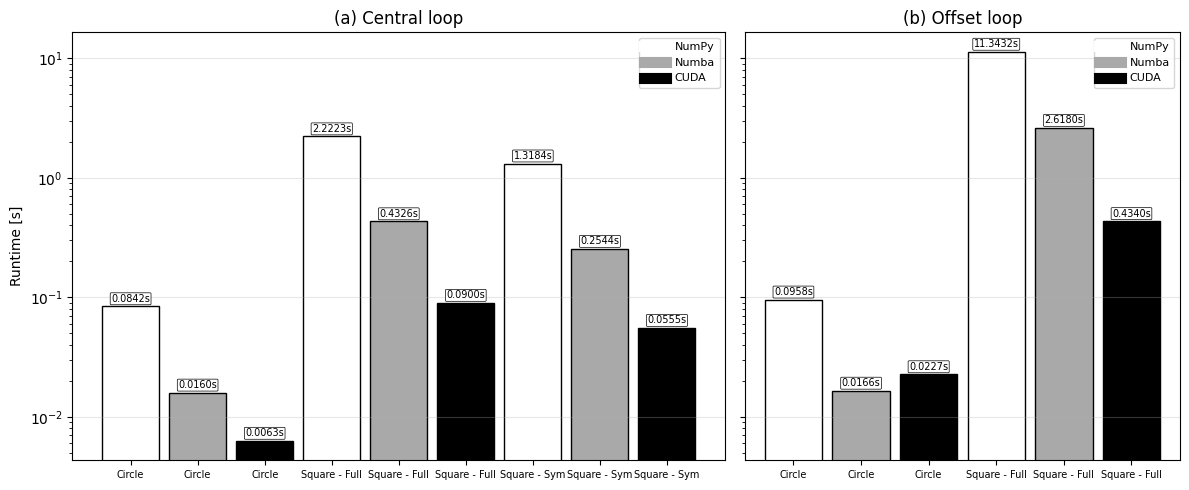

Central benchmark:
  Circle (np)               : 0.0842 s
  Circle (nb)               : 0.0160 s
  Circle (cuda)             : 0.0063 s
  Square - Full (np)        : 2.2223 s
  Square - Full (nb)        : 0.4326 s
  Square - Full (cuda)      : 0.0900 s
  Square - Sym (np)         : 1.3184 s
  Square - Sym (nb)         : 0.2544 s
  Square - Sym (cuda)       : 0.0555 s

Offset benchmark (r = 10 m):
  Circle (np)               : 0.0958 s
  Circle (nb)               : 0.0166 s
  Circle (cuda)             : 0.0227 s
  Square - Full (np)        : 11.3432 s
  Square - Full (nb)        : 2.6180 s
  Square - Full (cuda)      : 0.4340 s


In [7]:
# --- Plot runtimes ---
fig, axs = plt.subplots(1, 2, figsize=(12, 5),
                        gridspec_kw={'width_ratios': [9, 6]}, sharey=True)

def _bar_color(key):
    if '(cuda)' in key: return 'k'
    if '(nb)'  in key: return 'darkgrey'
    return 'w'

# Central systems
labels_c = list(results.keys())
times_c  = [results[k] for k in labels_c]
x_c      = np.arange(len(labels_c))
colors_c = [_bar_color(k) for k in labels_c]

bars_c = axs[0].bar(x_c, times_c, width=0.85, color=colors_c, edgecolor='black')
axs[0].set_ylabel('Runtime [s]')
axs[0].set_title('(a) Central loop')
axs[0].set_yscale('log')
axs[0].grid(True, axis='y', alpha=0.3)
axs[0].set_xticks(x_c)
axs[0].set_xticklabels(
    [k.replace(' (np)', '').replace(' (nb)', '').replace(' (cuda)', '') for k in labels_c],
    rotation=0, fontsize=7)

for bar, val in zip(bars_c, times_c):
    axs[0].text(bar.get_x() + bar.get_width() / 2, val * 1.05,
                f"{val:.4f}s", ha='center', va='bottom',
                bbox=dict(boxstyle='round,pad=0.1', facecolor='white', edgecolor='black', lw=0.5),
                fontsize=7)

# Offset systems
labels_o = list(results_offset.keys())
times_o  = [results_offset[k] for k in labels_o]
x_o      = np.arange(len(labels_o))
colors_o = [_bar_color(k) for k in labels_o]

bars_o = axs[1].bar(x_o, times_o, width=0.85, color=colors_o, edgecolor='black')
axs[1].set_title('(b) Offset loop')
axs[1].set_yscale('log')
axs[1].grid(True, axis='y', alpha=0.3)
axs[1].set_xticks(x_o)
axs[1].set_xticklabels(
    [k.replace(' (np)', '').replace(' (nb)', '').replace(' (cuda)', '') for k in labels_o],
    rotation=0, fontsize=7)

for bar, val in zip(bars_o, times_o):
    axs[1].text(bar.get_x() + bar.get_width() / 2, val * 1.05,
                f"{val:.4f}s", ha='center', va='bottom',
                bbox=dict(boxstyle='round,pad=0.1', facecolor='white', edgecolor='black', lw=0.5),
                fontsize=7)

legend_handles = [
    plt.Line2D([0], [0], color='w',        lw=8, markeredgecolor='black', label='NumPy'),
    plt.Line2D([0], [0], color='darkgrey', lw=8, label='Numba'),
]
if HAS_CUDA:
    legend_handles.append(plt.Line2D([0], [0], color='k', lw=8, label='CUDA'))
axs[0].legend(handles=legend_handles, loc='upper right', fontsize=8)
axs[1].legend(handles=legend_handles, loc='upper right', fontsize=8)

plt.tight_layout()
plt.show()

print("Central benchmark:")
for k, v in results.items():
    print(f"  {k:26s}: {v:.4f} s")

print(f"\nOffset benchmark (r = {_rx_bm:g} m):")
for k, v in results_offset.items():
    print(f"  {k:26s}: {v:.4f} s")

## 2. Synthetic Dataset

This notebook builds a synthetic central-loop TEM dataset, computes a 1-D Jacobian, and runs a regularised Gauss-Newton inversion.

| Symbol | Meaning |
|--------|---------|
| $\mathbf{d}$ | Observed data vector |
| $\mathbf{m}$ | Model vector, $\ln\rho$ |
| $F(\mathbf{m})$ | Forward response |
| $\mathbf{J}$ | Jacobian |
| $\mathbf{W}_d$ | Data weights |
| $\mathbf{R}$ | Roughness matrix |
| $\alpha$ | Regularisation weight |

---

We construct a synthetic 1-D model with a realistic resistivity profile, compute the noiseless forward response using `tem_forward_circle`, and then add a mixed noise model consisting of a relative component and a late-time noise floor:

$$\sigma_i = \sqrt{(\epsilon_\mathrm{rel}\,|d_i|)^2 + \sigma_\mathrm{floor}^2(t_i)}$$

where $\epsilon_\mathrm{rel} = 2\,\%$ and $\sigma_\mathrm{floor}(t) \propto t^{-1/2}$ mimics thermal noise that grows at late times.

In [8]:
times = np.logspace(-5, -2, 31)
loop_side = 50.0
L = loop_side
a = np.sqrt((L**2) / np.pi)

depths0 = np.array([0.0, 5.0, 10.0, 20.0, 30.0, 45.0, 100.0])
thicknesses0 = np.diff(depths0)

z = depths0[:-1]
z_norm = (z - z.min()) / (z.max() - z.min())

base_trend = 180 - 80 * z_norm
undulation = 50 * np.sin(2 * np.pi * 1.2 * z_norm)
shallow_high = 10 * np.exp(-0.5 * ((z_norm - 0.18) / 0.10) ** 2)
mid_low = -50 * np.exp(-0.5 * ((z_norm - 0.60) / 0.12) ** 2)
deep_high = 10 * np.exp(-0.5 * ((z_norm - 0.88) / 0.08) ** 2)
rho0 = base_trend + undulation + shallow_high + mid_low + deep_high

rel_noise = 0.02
noise_at_1ms = 1e-10

obs_data = tem_forward_circle(
    thicknesses=thicknesses0,
    resistivities=rho0,
    tx_radius=a,
    times=times,
    use_numba=False,
)

noise_floor = noise_at_1ms * (times / 1e-3) ** (-0.5)
noise_std = np.sqrt((rel_noise * np.abs(obs_data)) ** 2 + noise_floor ** 2)
obs_data += np.random.normal(size=obs_data.shape) * noise_std

## 3. Inversion Theory

Following Constable, Parker & Constable (1987, *Occam's inversion*, Geophysics 52, 289-300) and Binley & Slater (2020, *Resistivity and Induced Polarization*, Cambridge University Press, Ch. 6), we recover the 1-D log-resistivity model $\mathbf{m} = \ln\boldsymbol{\rho}$ by minimising a regularised objective function:

$$\Phi(\mathbf{m}) = \Phi_d(\mathbf{m}) + \alpha\,\Phi_m(\mathbf{m})$$

$$\Phi_d = \|\mathbf{W}_d\bigl(\ln\mathbf{d} - \ln F(\mathbf{m})\bigr)\|_2^2, \qquad \Phi_m = (\mathbf{m}-\mathbf{m}_{ref})^T \mathbf{R}\,(\mathbf{m}-\mathbf{m}_{ref})$$

where $\mathbf{W}_d = \mathrm{diag}(1/\sigma_i)$ is a diagonal data-weighting matrix, $\mathbf{R}$ is the first-order roughness (smoothness) matrix, and $\alpha$ is the regularisation parameter that controls the trade-off between data fit and model smoothness.

At each Gauss-Newton iteration the model update $\Delta\mathbf{m}$ is found by solving:

$$\left(\mathbf{J}_w^T\mathbf{J}_w + \alpha\,\mathbf{R}\right)\Delta\mathbf{m} = \mathbf{J}_w^T\mathbf{r}_w - \alpha\,\mathbf{R}(\mathbf{m}_k - \mathbf{m}_{ref})$$

where $\mathbf{J}_w = \mathbf{W}_d\,\mathbf{J}$ and $\mathbf{r}_w = \mathbf{W}_d(\ln\mathbf{d} - \ln F(\mathbf{m}_k))$.

> **Key requirement on $F$:** For a 28-layer mesh, building $\mathbf{J}$ by finite differences requires 29 forward calls per iteration, plus further calls in the $\alpha$ line search. Across 15-30 iterations a typical run involves more than 500 forward evaluations. Section 1 focused on making $F$ as fast as possible precisely for this reason. Section 3.1 below goes one step further: by computing $\mathbf{J}$ analytically, all $N$ columns are obtained in roughly $2\times$ the cost of a single forward call.


### 3.1 Analytical Jacobian

Constable, Parker & Constable (1987, Appendix) showed that for a layered-earth kernel built from a downward recursion, **the partial derivatives with respect to each layer resistivity can be propagated backward through the same stored intermediate values** used in the forward calculation, giving the full Jacobian in $\mathcal{O}(N)$ extra work rather than $N$ separate forward runs. They derived this for the Schlumberger DC-resistivity kernel (the Koefoed transform recursion) and for the MT complex C-value recursion.

The TEM forward model uses a different kernel entirely: the TE reflection coefficient $r_\mathrm{TE}(\lambda, \omega)$ evaluated over horizontal wavenumber $\lambda$ and a set of Laplace frequencies $\omega$, transformed to the time domain by digital linear filters (DLF). Constable et al. did not consider TEM; the derivation below is inspired by their backward-differentiation approach but is developed independently for the TEM TE-mode kernel.

#### TE-mode reflection coefficient recursion

The vertical wavenumber in layer $j$ is:

$$\Gamma_j(\lambda, \omega) = \sqrt{\lambda^2 + \frac{i\omega\mu_0}{\rho_j}}$$

where $\lambda$ is the horizontal wavenumber and $\omega$ is angular frequency. The upward-propagating TE reflection coefficient just below the surface is built by the downward recursion (starting from $r_N = 0$ at the base of the last layer):

$$r_j = e^{-2\Gamma_j h_j}\,\frac{r_{j+1} + p_j}{1 + r_{j+1}\,p_j}, \qquad p_j = \frac{\Gamma_j - \Gamma_{j+1}}{\Gamma_j + \Gamma_{j+1}}$$

At the surface:

$$r_\mathrm{TE}(\lambda,\omega) = \frac{r_1 + p_0}{1 + r_1\,p_0}, \qquad p_0 = \frac{\lambda - \Gamma_0}{\lambda + \Gamma_0}$$

The DLF Hankel transform then gives $\dot{B}(t)$ at each gate.

#### Differentiating through the recursion

Because $\Gamma_j$ depends on $\rho_j$ via

$$\frac{\partial \Gamma_j}{\partial \rho_j} = -\frac{i\omega\mu_0}{2\,\rho_j^2\,\Gamma_j}$$

the chain rule is propagated **backward** through the stored intermediates $r_j$ and $e^{-2\Gamma_j h_j}$, yielding $\partial r_\mathrm{TE}/\partial \rho_j$ for every layer $j$ in $\mathcal{O}(N)$ operations per $(\lambda, \omega)$ pair. The same Fourier DLF filters used in the forward transform then convert the frequency-domain sensitivity to time-domain gate sensitivities.

The final log-space Jacobian element is:

$$J_{ij} = \frac{\partial \ln(-\dot{B}_i)}{\partial \ln\rho_j} = \frac{1}{-\dot{B}_i}\,\frac{\partial(-\dot{B}_i)}{\partial \ln\rho_j}$$

#### Computational cost

| Method | Forward calls per iteration | Notes |
|--------|---------------------------|-------|
| Finite differences | $N + 1$ | One baseline + one per layer |
| Analytical (this implementation) | $\approx 2$ equivalent | Gradient propagated through the same recursion |

For the 28-layer mesh used here the analytical approach is roughly **15× faster** per Jacobian build (see the comparison in Section 3.2).


In [9]:
def getRMS(obs_data, mod_data, obs_noise):
    """Root-mean-square misfit normalised by noise."""
    total_points = obs_data.size
    data_residual = (mod_data - obs_data) ** 2 / (obs_noise) ** 2
    rms = np.sqrt(np.sum(data_residual) / total_points)
    return rms


def getAlpha(alpha_start, step):
    """Log-spaced regularisation parameter for a given cooling step."""
    alpha_step = 1 / 9
    log_alpha = np.log10(alpha_start) - alpha_step * step
    alpha = 10 ** log_alpha
    return alpha


def getAlphas(alpha, thicknesses):
    """Depth-weighted regularisation vector."""
    thicknesses = np.asarray(thicknesses)
    tops = np.cumsum(np.concatenate(([0], thicknesses[:-1])))
    midpoints = tops + thicknesses / 2.0
    del_z = np.diff(midpoints)
    alpha_factor = np.empty(len(del_z) + 1, dtype=del_z.dtype)
    alpha_factor[0] = 1 / del_z[0]
    alpha_factor[1:-1] = 1 / del_z[:-1] + 1 / del_z[1:]
    alpha_factor[-1] = 1 / del_z[-1]
    return alpha * alpha_factor


def getR(resistivities, damp=1e-4):
    """First-order roughness (smoothness) matrix with optional damping."""
    n_params = resistivities.size
    D = np.zeros((n_params - 1, n_params))
    for k in range(n_params - 1):
        D[k, k] = -1.0
        D[k, k + 1] = 1.0
    R = D.T @ D + damp * np.eye(n_params)
    return R


def getJ(thicknesses, log_resistivities, tx_geom, times,
         use_numba=False, use_cuda=True, eps=1e-4, fwd=tem_forward_circle,
         transform='dlf', hankel_filter='key_201', fourier_filter='key_81',
         euler_order=11):
    """Finite-difference Jacobian d(log(-dBdt))/d(ln rho)."""
    f0 = -fwd(
        thicknesses=thicknesses,
        resistivities=np.exp(log_resistivities),
        tx_radius=tx_geom,
        times=times,
        use_numba=use_numba,
        use_cuda=use_cuda,
        transform=transform,
        hankel_filter=hankel_filter,
        fourier_filter=fourier_filter,
        euler_order=euler_order,
    )

    bad_f0 = f0 <= 0
    if np.any(bad_f0):
        print(f"WARNING: f0 has {bad_f0.sum()} non-positive values at gate indices {np.where(bad_f0)[0]} (zeroed in J)")

    J = np.zeros((f0.size, log_resistivities.size))
    bad_count = 0
    for i in range(log_resistivities.size):
        perturbed = log_resistivities.copy()
        step = eps * max(1.0, abs(log_resistivities[i]))
        perturbed[i] += step

        fi = -fwd(
            thicknesses=thicknesses,
            resistivities=np.exp(perturbed),
            tx_radius=tx_geom,
            times=times,
            use_numba=use_numba,
            use_cuda=use_cuda,
            transform=transform,
            hankel_filter=hankel_filter,
            fourier_filter=fourier_filter,
            euler_order=euler_order,
        )

        valid = (f0 > 0) & (fi > 0)
        if not np.all(valid):
            bad_count += 1
        J[valid, i] = (np.log(fi[valid]) - np.log(f0[valid])) / step

    if bad_count:
        print(f"WARNING: {bad_count}/{log_resistivities.size} perturbed models had non-positive values (zeroed in J)")

    return J


def getJ_analytical(thicknesses, log_resistivities, tx_radius, times,
                    hankel_filter='key_101', fourier_filter='key_101'):
    """Analytical Jacobian d(ln(-dBdt_i))/d(ln rho_j) for a central-loop
    circle geometry.

    Implements backward differentiation through the TE-mode DLF recursion.
    Inspired by Constable, Parker & Constable (1987) who applied the same
    strategy to Schlumberger and MT kernels; the TEM TE-mode derivation here
    is independent.

    Parameters
    ----------
    thicknesses       : array_like, shape (N-1,)
    log_resistivities : array_like, shape (N,)
    tx_radius         : float  — transmitter loop radius [m]
    times             : array_like, shape (T,)
    hankel_filter     : str   — key in HANKEL_FILTERS
    fourier_filter    : str   — key in FOURIER_FILTERS

    Returns
    -------
    J : ndarray, shape (T, N)
    """
    thick = np.asarray(thicknesses, dtype=float)
    rho   = np.exp(np.asarray(log_resistivities, dtype=float))
    times = np.asarray(times, dtype=float)
    n_lay = len(rho)
    n_t   = len(times)

    h_base, _h_j0, h_j1 = HANKEL_FILTERS[hankel_filter]
    f_base, f_sin, _    = FOURIER_FILTERS[fourier_filter]

    lam  = h_base / float(tx_radius)   # (K,) Hankel quadrature points
    lam2 = lam ** 2

    sigma = (1.0 / rho).astype(complex)  # (N,)

    dbdt   = np.zeros(n_t)
    d_dbdt = np.zeros((n_lay, n_t))      # d(dbdt_i)/d(ln rho_j)

    for i in range(n_t):
        omegas = f_base / times[i]   # (M,) Laplace frequencies for this gate
        sval   = 1j * omegas         # (M,)

        # Gamma[j, m, k] = sqrt(lam^2 + i*omega*mu0/rho_j)
        # dG[j, m, k]    = d(Gamma_j)/d(ln rho_j)  (log-space derivative)
        Gamma = np.sqrt(lam2[None, None, :]
                        + sval[None, :, None] * MU0 * sigma[:, None, None])
        dG    = -sval[None, :, None] * MU0 * sigma[:, None, None] / (2.0 * Gamma)

        M = len(omegas)
        K = len(lam)

        # Downward recursion — store r_j and exp factors
        r     = np.zeros((M, K), dtype=complex)
        r_st  = np.empty((n_lay,     M, K), dtype=complex)
        e_st  = np.empty((n_lay - 1, M, K), dtype=complex)
        r_st[n_lay - 1] = 0.0                                # half-space b.c.

        for j in range(n_lay - 2, -1, -1):
            ej       = np.exp(-2.0 * Gamma[j] * thick[j])
            e_st[j]  = ej
            ps       = (Gamma[j] - Gamma[j + 1]) / (Gamma[j] + Gamma[j + 1])
            r        = ej * (r + ps) / (1.0 + r * ps)
            r_st[j]  = r

        # Surface TE reflection coefficient
        pa   = (lam[None, :] - Gamma[0]) / (lam[None, :] + Gamma[0])
        da   = 1.0 + r_st[0] * pa
        r_TE = (r_st[0] + pa) / da       # (M, K)

        # Hz at surface (circle, central receiver)
        hz  = 0.5 * np.sum(r_TE * lam[None, :] * h_j1[None, :], axis=1)  # (M,)
        sig = MU0 * np.imag(hz)
        dbdt[i] = np.dot(sig, f_sin) / times[i]

        # Backward pass — propagate d(r_TE)/d(ln rho_j) for all j
        adj  = (1.0 - pa ** 2) / da ** 2
        dpg0 = -2.0 * lam[None, :] / (lam[None, :] + Gamma[0]) ** 2
        drpa = (1.0 - r_st[0] ** 2) / da ** 2

        dr = np.zeros((n_lay, M, K), dtype=complex)
        dr[0] += drpa * dpg0 * dG[0]

        for j in range(n_lay - 1):
            rb   = r_st[j + 1]
            ej   = e_st[j]
            gs   = Gamma[j] + Gamma[j + 1]
            ps   = (Gamma[j] - Gamma[j + 1]) / gs
            den  = 1.0 + rb * ps
            num  = rb + ps
            drps = ej * (1.0 - rb ** 2) / den ** 2
            dej  = -2.0 * thick[j] * ej
            dr[j]     += adj * (dej * num / den + drps * 2.0 * Gamma[j + 1] / gs ** 2) * dG[j]
            dr[j + 1] += adj * drps * (-2.0 * Gamma[j] / gs ** 2) * dG[j + 1]
            adj = adj * ej * (1.0 - ps ** 2) / den ** 2

        # d(Hz)/d(ln rho_j) via same Hankel weights
        dhz    = 0.5 * np.sum(dr * lam[None, None, :] * h_j1[None, None, :], axis=2)  # (N, M)
        dsig   = MU0 * np.imag(dhz)
        d_dbdt[:, i] = np.sum(dsig * f_sin[None, :], axis=1) / times[i]

    dbdt   *= 2.0 / np.pi
    d_dbdt *= 2.0 / np.pi

    # Log-space Jacobian: J_ij = d(ln(-dbdt_i))/d(ln rho_j)
    f0 = -dbdt
    J  = np.zeros((n_t, n_lay))
    valid = f0 > 0
    for j in range(n_lay):
        J[valid, j] = d_dbdt[j, valid] / dbdt[valid]
    return J


## 4. Inversion Setup

The inversion uses a 1-D log-spaced layered mesh with a homogeneous starting model. The forward model is bound to `fwd = tem_forward_circle` as chosen in the cell above.

In [10]:
depths = np.array([1., 2.088, 3.272, 4.56, 5.962, 7.487, 9.147,
                   10.953, 12.918, 15.056, 17.382, 19.913, 22.667, 
                   25.664, 28.925, 32.473, 36.334, 40.535, 45.106, 
                   50.08 , 55.492, 61.381, 67.789, 74.762, 82.349, 
                   90.604, 99.587, 109.361, 120.001])

thicknesses = np.diff(depths).tolist()
log_resistivities = np.ones_like(thicknesses) * 4.5

In [11]:
# ============================================================================
# Forward model choice for inversion
# ============================================================================
# Section 1 showed that the central-loop circle geometry is the fastest
# option (no side integration required) and the 101-pt DLF is accurate to
# < 0.1 % relative to the 201-pt reference.  We bind these choices here so
# the rest of the notebook uses a single, easy-to-swap definition.

fwd          = tem_forward_circle   # forward model function
FWD_HANKEL   = 'key_101'            # Hankel filter
FWD_FOURIER  = 'key_101'            # Fourier filter
FWD_NUMBA    = HAS_NUMBA            # use Numba JIT if available
FWD_CUDA     = HAS_CUDA             # use CUDA if available

print(f"Forward model : tem_forward_circle")
print(f"Hankel filter : {FWD_HANKEL}")
print(f"Fourier filter: {FWD_FOURIER}")
print(f"Numba         : {FWD_NUMBA}")
print(f"CUDA          : {FWD_CUDA}")

Forward model : tem_forward_circle
Hankel filter : key_101
Fourier filter: key_101
Numba         : True
CUDA          : True


In [12]:
J = getJ(thicknesses=thicknesses, log_resistivities=log_resistivities, 
         tx_geom=L, times=times, use_cuda=True, eps=1e-4, fwd=tem_forward_circle,
         transform='dlf', hankel_filter='key_101', fourier_filter='key_101', euler_order=15)

### 3.2 Validation: Analytical vs Finite-difference Jacobian

`getJ_analytical` (defined above) is compared against two finite-difference baselines:

1. **FD + DLF** — `getJ` with the `key_101` Hankel and Fourier filters.
2. **FD + Euler–Stehfest** — `getJ` with the Euler inverse-Laplace transform at each available order.

All methods are evaluated on the homogeneous starting model. The timing table and plots show both the relative accuracy (vs the analytical result) and the wall-clock cost.


Method                                   Time [s]  Max rel. err vs analytical
-------------------------------------------------------------------------------
  Analytical (NumPy, this notebook)         1.894                           —
  FD  DLF  key_101 / key_101               55.382                    3.80e-02
  FD  Euler  order=8                       11.206                    1.10e+01
  FD  Euler  order=11                      12.416                    1.55e+01
  FD  Euler  order=15                      17.421                    1.45e+01
  FD  Euler  order=19                      39.247                    1.41e+01


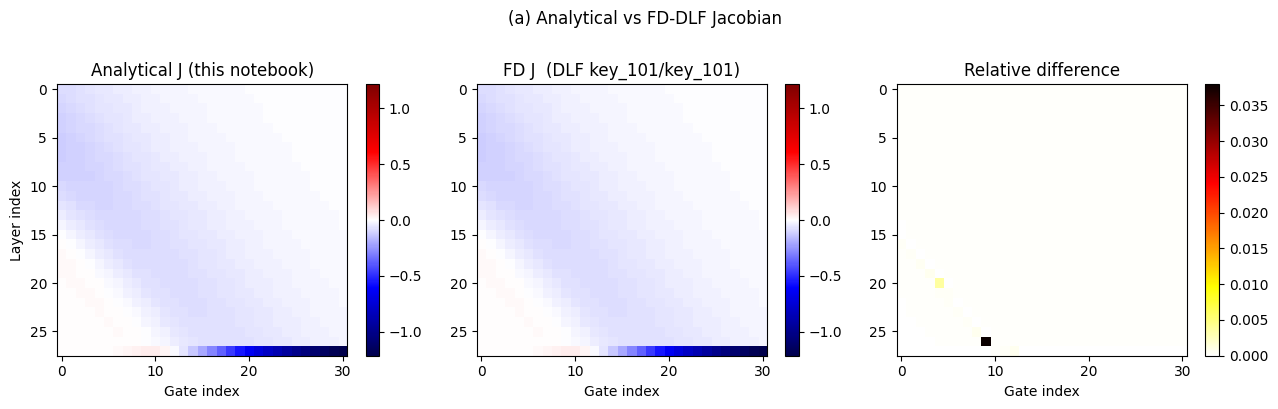

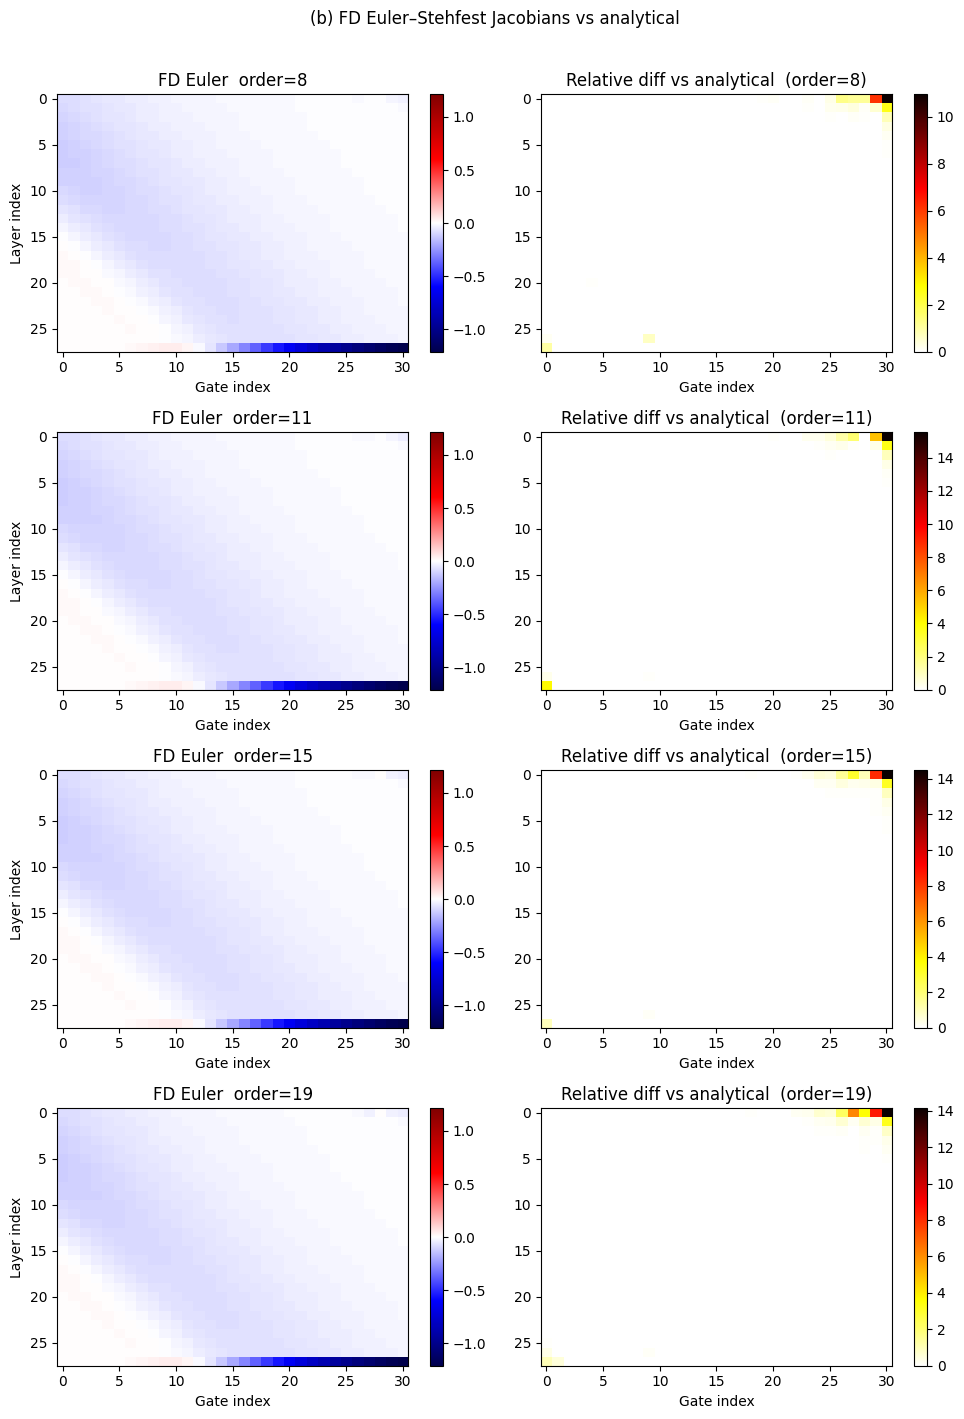

In [13]:
# ============================================================================
# 3.2  Analytical vs finite-difference Jacobian
# ============================================================================

def _rel_err(J_ref, J_test):
    """Max relative error of J_test w.r.t. J_ref (ignores near-zero entries)."""
    ab   = np.abs(J_ref)
    mask = ab > 1e-12 * ab.max()
    rd   = np.zeros_like(J_ref)
    rd[mask] = np.abs(J_test[mask] - J_ref[mask]) / ab[mask]
    return rd


# --- Analytical (pure NumPy, defined in this notebook) ---
t0 = time.perf_counter()
J_an = getJ_analytical(
    thicknesses=thicknesses,
    log_resistivities=log_resistivities,
    tx_radius=a,
    times=times,
    hankel_filter='key_101',
    fourier_filter='key_101',
)
t_an = time.perf_counter() - t0

# --- FD + DLF (key_101 / key_101) ---
t0 = time.perf_counter()
J_fd_dlf = getJ(
    thicknesses=thicknesses,
    log_resistivities=log_resistivities,
    tx_geom=a,
    times=times,
    use_numba=False, use_cuda=False,
    fwd=tem_forward_circle,
    transform='dlf',
    hankel_filter='key_101',
    fourier_filter='key_101',
)
t_fd_dlf = time.perf_counter() - t0

# --- FD + Euler–Stehfest (all available orders) ---
euler_orders = list(EULER_PARAMS)
J_fd_euler   = {}
t_fd_euler   = {}
for _ord in euler_orders:
    t0 = time.perf_counter()
    J_fd_euler[_ord] = getJ(
        thicknesses=thicknesses,
        log_resistivities=log_resistivities,
        tx_geom=a,
        times=times,
        use_numba=False, use_cuda=False,
        fwd=tem_forward_circle,
        transform='euler',
        hankel_filter='key_101',
        euler_order=_ord,
    )
    t_fd_euler[_ord] = time.perf_counter() - t0

# --- Timing + accuracy table ---
print(f"{'Method':38s}  {'Time [s]':>9s}  {'Max rel. err vs analytical':>26s}")
print("-" * 79)
print(f"  {'Analytical (NumPy, this notebook)':36s}  {t_an:9.3f}  {'—':>26s}")
rd_dlf = _rel_err(J_an, J_fd_dlf)
print(f"  {'FD  DLF  key_101 / key_101':36s}  {t_fd_dlf:9.3f}  {rd_dlf.max():26.2e}")
for _ord in euler_orders:
    rd = _rel_err(J_an, J_fd_euler[_ord])
    print(f"  {f'FD  Euler  order={_ord}':36s}  {t_fd_euler[_ord]:9.3f}  {rd.max():26.2e}")

# ============================================================
# Figure (a): Analytical | FD-DLF | Relative difference
# ============================================================
vmax = max(np.abs(J_an).max(), np.abs(J_fd_dlf).max())
kw   = dict(aspect='auto', cmap='seismic', vmin=-vmax, vmax=vmax)

fig, axs = plt.subplots(1, 3, figsize=(13, 4))

im0 = axs[0].imshow(J_an.T, **kw)
axs[0].set_title('Analytical J (this notebook)')
axs[0].set_xlabel('Gate index')
axs[0].set_ylabel('Layer index')
plt.colorbar(im0, ax=axs[0])

im1 = axs[1].imshow(J_fd_dlf.T, **kw)
axs[1].set_title('FD J  (DLF key_101/key_101)')
axs[1].set_xlabel('Gate index')
plt.colorbar(im1, ax=axs[1])

im2 = axs[2].imshow(rd_dlf.T, aspect='auto', cmap='hot_r', vmin=0)
axs[2].set_title('Relative difference')
axs[2].set_xlabel('Gate index')
plt.colorbar(im2, ax=axs[2])

fig.suptitle('(a) Analytical vs FD-DLF Jacobian', y=1.01)
fig.tight_layout()
plt.show()

# ============================================================
# Figure (b): FD Euler orders — J and relative diff vs analytical
# ============================================================
n_ord = len(euler_orders)
fig, axs = plt.subplots(n_ord, 2, figsize=(10, 3.5 * n_ord), squeeze=False)

for row, _ord in enumerate(euler_orders):
    J_e    = J_fd_euler[_ord]
    vmax_e = max(np.abs(J_an).max(), np.abs(J_e).max())
    kw_e   = dict(aspect='auto', cmap='seismic', vmin=-vmax_e, vmax=vmax_e)

    im_j = axs[row, 0].imshow(J_e.T, **kw_e)
    axs[row, 0].set_title(f'FD Euler  order={_ord}')
    axs[row, 0].set_xlabel('Gate index')
    axs[row, 0].set_ylabel('Layer index')
    plt.colorbar(im_j, ax=axs[row, 0])

    rd_e = _rel_err(J_an, J_e)
    im_r = axs[row, 1].imshow(rd_e.T, aspect='auto', cmap='hot_r', vmin=0)
    axs[row, 1].set_title(f'Relative diff vs analytical  (order={_ord})')
    axs[row, 1].set_xlabel('Gate index')
    plt.colorbar(im_r, ax=axs[row, 1])

fig.suptitle('(b) FD Euler–Stehfest Jacobians vs analytical', y=1.01)
fig.tight_layout()
plt.show()


In [14]:
def dbdt_to_apprho(obs_data, tx_area, times):
    """Convert dB/dt to apparent resistivity."""
    M = tx_area
    term = (2 * MU0 * M) / (5 * times * obs_data)
    app_rho = (MU0 / (4 * np.pi * times)) * (term ** (2 / 3))
    return app_rho

## 5. Jacobian and Regularisation

Before running the inversion, the finite-difference Jacobian is inspected to confirm the expected depth and gate sensitivity structure. The smoothness matrix $\mathbf{R}$ is also visualised.

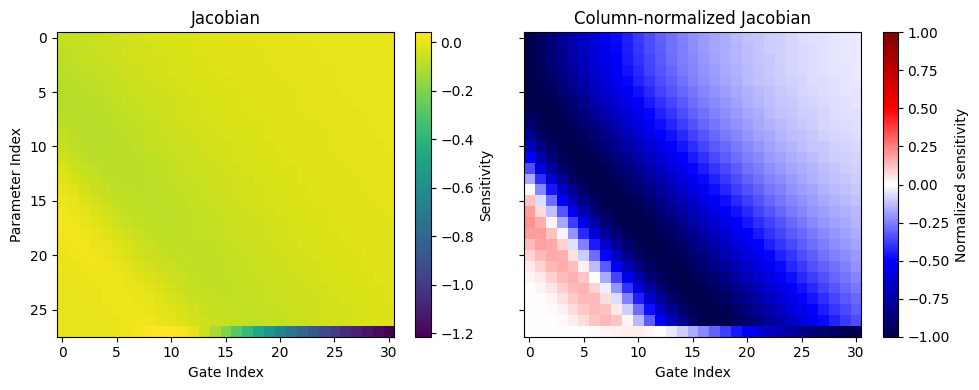

In [15]:
sens_normalized = J / np.abs(J).max(axis=0, keepdims=True)

fig, axs = plt.subplots(1, 2, figsize=(10, 4), sharey=True)

im0 = axs[0].imshow(J.T, aspect='auto', cmap='viridis')
plt.colorbar(im0, ax=axs[0]).set_label('Sensitivity')
axs[0].set_title('Jacobian')
axs[0].set_ylabel('Parameter Index')
axs[0].set_xlabel('Gate Index')

im1 = axs[1].imshow(sens_normalized.T, aspect='auto', cmap='seismic', vmin=-1, vmax=1)
plt.colorbar(im1, ax=axs[1]).set_label('Normalized sensitivity')
axs[1].set_title('Column-normalized Jacobian')
axs[1].set_xlabel('Gate Index')

fig.tight_layout()

### Smoothness and Regularisation

The roughness matrix $\mathbf{R} = \mathbf{D}^T\mathbf{D} + \delta\mathbf{I}$ is built from the first-difference operator $\mathbf{D}$, which penalises sharp jumps in $\ln\rho$ between adjacent layers. A small damping term $\delta$ ensures $\mathbf{R}$ is invertible.

`getAlphas()` applies a depth-weighting so that the penalty per unit log-resistivity change is proportional to the inverse of the layer midpoint spacing. This prevents thin layers near the surface from being over-regularised relative to the thick deep layers.

The regularisation parameter $\alpha$ is cooled over iterations using a log-linear schedule (`getAlpha()`): large early to stabilise convergence, then reduced to allow finer structure as the data misfit approaches 1.

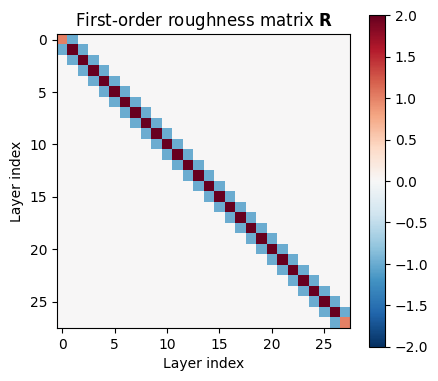

R shape: (28, 28),  diagonal range: 1.000 – 2.000


In [16]:
# ============================================================================
# Roughness matrix visualisation
# ============================================================================
R_vis = getR(np.array(thicknesses))

fig, ax = plt.subplots(figsize=(4.5, 4))
im = ax.imshow(R_vis, cmap='RdBu_r', vmin=-R_vis.max(), vmax=R_vis.max())
plt.colorbar(im, ax=ax)
ax.set_title('First-order roughness matrix $\\mathbf{R}$')
ax.set_xlabel('Layer index')
ax.set_ylabel('Layer index')
fig.tight_layout()
plt.show()

print(f"R shape: {R_vis.shape},  diagonal range: {R_vis.diagonal().min():.3f} – {R_vis.diagonal().max():.3f}")

## 6. Regularised Gauss-Newton Inversion

Following Constable, Parker & Constable (1987, *Geophysics*, 52, 289–300), the update at each iteration solves:

$$\left(\mathbf{J}_w^T\mathbf{J}_w + \alpha\,\mathbf{R}\right)\Delta\mathbf{m} = \mathbf{J}_w^T\mathbf{d}_w$$

The regularisation parameter $\alpha$ is cooled across iterations using the schedule from Constable et al. (1987). Within each iteration a short line search over $\alpha$ is run, and a parabola is fitted in $\log_{10}\alpha$ space through the sampled (RMS, $\alpha$) pairs. The parabola minimum gives a refined $\alpha$ estimate without extra forward calls, following the spirit of the $\chi^2$ target approach in Constable et al. (1987).

The Jacobian is computed analytically by propagating the TE-mode gradient through the same DLF recursion as the forward model (no finite-difference perturbations). See also Binley & Slater (2020, *Resistivity and Induced Polarization*, Cambridge University Press, Ch. 6).


In [17]:
def invert(obs_data, thicknesses, log_resistivities, tx_radius, times, alpha_start=None, alpha_steps=5, maxit=10, eps=1e-4, noise_std=0.02,
           use_numba=False, use_cuda=True, calc_sens=False, store_J=False,
           use_analytical_J=True,
           transform='dlf', hankel_filter='key_101', fourier_filter='key_101', euler_order=11,
           rho_min=1e-1, rho_max=1e5, ref_model=None, ref_weight=1.0):
    """Regularized Gauss-Newton inversion in log-resistivity space.

    The model objective uses a reference model term:
        phi_m = ref_weight * (m - m_ref)^T R (m - m_ref)

    Parameters
    ----------
    use_analytical_J : bool, optional
        If True (default), build the Jacobian analytically via
        ``getJ_analytical``.  Set to False to fall back to finite differences
        via ``getJ``.
    """
    start_time = time.time()

    obs_data_full = np.asarray(obs_data, dtype=float)
    times_full = np.asarray(times, dtype=float)
    if obs_data_full.shape != times_full.shape:
        raise ValueError("obs_data and times must have the same shape")

    print(f"DATA POINTS READ: {obs_data_full.size}")
    valid_obs = obs_data_full > 0
    removed_idx = np.where(~valid_obs)[0]
    print(f"DATA POINTS {removed_idx.size} REMOVED at gate index {removed_idx.tolist()} due to non-positive values")

    if removed_idx.size == obs_data_full.size:
        raise ValueError("All observed data points are non-positive after filtering")

    obs_data = obs_data_full[valid_obs]
    times_inv = times_full[valid_obs]

    if isinstance(noise_std, (int, float)):
        noise_std_inv = float(noise_std)
    else:
        noise_std_full = np.asarray(noise_std, dtype=float)
        if noise_std_full.shape != obs_data_full.shape:
            raise ValueError("noise_std must have same shape as obs_data when array-like")
        noise_std_inv = noise_std_full[valid_obs]

    def _forward_response(log_rho, use_full_times=False):
        forward_times = times_full if use_full_times else times_inv
        return -tem_forward_circle(
            thicknesses=thicknesses,
            resistivities=np.exp(log_rho),
            tx_radius=tx_radius,
            times=forward_times,
            use_numba=use_numba,
            use_cuda=use_cuda,
            transform=transform,
            hankel_filter=hankel_filter,
            fourier_filter=fourier_filter,
            euler_order=euler_order,
        )

    def _compute_J(log_rho, times_j):
        if use_analytical_J:
            return getJ_analytical(
                thicknesses=thicknesses,
                log_resistivities=log_rho,
                tx_radius=tx_radius,
                times=times_j,
                hankel_filter=hankel_filter,
                fourier_filter=fourier_filter,
            )
        return getJ(
            thicknesses=thicknesses,
            log_resistivities=log_rho,
            tx_geom=tx_radius,
            times=times_j,
            use_numba=use_numba,
            use_cuda=use_cuda,
            eps=eps,
            fwd=tem_forward_circle,
            transform=transform,
            hankel_filter=hankel_filter,
            fourier_filter=fourier_filter,
            euler_order=euler_order,
        )

    app_res = np.mean(dbdt_to_apprho(obs_data, np.pi * tx_radius**2, times_inv))

    m = np.asarray(log_resistivities, dtype=float).copy()
    m_ref = m.copy() if ref_model is None else np.asarray(ref_model, dtype=float)
    if m_ref.shape != m.shape:
        raise ValueError("ref_model must have same shape as log_resistivities")

    R = getR(m)
    R_ref = ref_weight * R

    j_method = "analytical" if use_analytical_J else "finite-difference"
    print(f"DATA POINTS USED: {obs_data.size}")
    print(f"REFERENCE MODEL WEIGHT: {ref_weight:.2f}")
    print(f"JACOBIAN METHOD: {j_method}")

    # Data weights w = 1/sigma in log space
    if isinstance(noise_std_inv, float):
        sigma_log = np.full(obs_data.size, noise_std_inv)
        print(f"MEAN LATE-TIME APPARENT RESISTIVITY: {app_res:.2f} Ohm.m, NOISE: {noise_std_inv*100:.2f}%")
    else:
        sigma_log = noise_std_inv / np.abs(obs_data)
        print(
            "MEAN LATE-TIME APPARENT RESISTIVITY: "
            f"{app_res:.2f} Ohm.m, NOISE STD: min={noise_std_inv.min():.2e}, max={noise_std_inv.max():.2e}"
        )
    w = 1.0 / sigma_log

    alpha_unit = getAlphas(1.0, thicknesses)
    R_alpha = np.diag(alpha_unit) @ R_ref

    ln_rho_min = np.log(rho_min)
    ln_rho_max = np.log(rho_max)

    iter_rms_list = []
    iter_roughness_list = []
    rho_hist = []
    if store_J:
        J_hist = []

    print("\nSTARTING INVERSION...")

    for it in range(maxit):
        print(f"\nITERATION {it + 1}")

        mod_data = _forward_response(m, use_full_times=False)
        d = np.log(obs_data) - np.log(mod_data)

        rms = np.sqrt(np.mean((w * d) ** 2))
        dm_ref = m - m_ref
        phi_m = dm_ref @ R_ref @ dm_ref
        print(f"    Initial Data Misfit: {rms:.4f},  Model Misfit: {phi_m:.4f}")

        J = _compute_J(m, times_inv)

        if store_J:
            J_hist.append(J.copy())

        Jw = w[:, None] * J
        dw = w * d

        if it == 0 and alpha_start is None:
            JtJ = Jw.T @ Jw
            alpha_start = np.trace(JtJ) / np.trace(R_alpha)
            print(f"    No alpha specified, using: {alpha_start:.2f}")

        alpha_hist = []
        rms_hist = []
        delta_hist = []

        if it != 0:
            alpha_start = alpha_new

        for i in range(alpha_steps):
            alpha_temp = getAlpha(alpha_start, step=i)

            alpha_vector = getAlphas(alpha_temp, thicknesses)
            alpha_matrix = np.diag(alpha_vector)

            lhs = Jw.T @ Jw + alpha_matrix @ R_ref
            rhs = Jw.T @ dw - alpha_matrix @ (R_ref @ (m - m_ref))

            delta = np.linalg.solve(lhs, rhs)

            step = 1.0
            for _ in range(10):
                trial = m + step * delta
                if np.all(trial >= ln_rho_min) and np.all(trial <= ln_rho_max):
                    break
                step *= 0.5
            else:
                trial = np.clip(m + step * delta, ln_rho_min, ln_rho_max)

            delta_hist.append(trial - m)

            mod_data_trial = _forward_response(trial, use_full_times=False)
            d_trial = np.log(obs_data) - np.log(mod_data_trial)
            rms_trial = np.sqrt(np.mean((w * d_trial) ** 2))

            print(
                f"    Alpha: {alpha_temp:.2f}, Data Misfit: {rms_trial:.4f}"
                + (f" (step={step:.2f})" if step < 1.0 else "")
            )
            alpha_hist.append(alpha_temp)
            rms_hist.append(rms_trial)

            if len(rms_hist) > 2 and rms_hist[-1] > np.min(rms_hist[:-1]):
                break

        best_idx = np.argmin(rms_hist)
        print(f"    Best Data Misfit: {rms_hist[best_idx]:.4f}")

        iter_rms_list.append(rms_hist[best_idx])

        m = m + delta_hist[best_idx]
        resistivities = np.exp(m)
        rho_hist.append(resistivities.copy())

        dm_ref = m - m_ref
        phi_m = dm_ref @ R_ref @ dm_ref
        iter_roughness_list.append(phi_m)

        alpha_best = alpha_hist[best_idx]
        chi = max(iter_rms_list[-1], 1.01)
        alpha_decay = np.log10(0.588) / np.log10(chi)
        alpha_new = alpha_best * 0.5 * chi ** (-alpha_decay)

        if it >= 2:
            recent_rms = iter_rms_list[-3:]
            if np.std(recent_rms) < eps * np.mean(recent_rms):
                print("\nCONVERGENCE ACHIEVED BASED ON chi STABILITY.")
                break

    best_rho = rho_hist[np.argmin(iter_rms_list)]
    best_rms = np.min(iter_rms_list)

    mod_data = _forward_response(np.log(best_rho), use_full_times=True)

    print(f"\nTOTAL INVERSION TIME: {(time.time() - start_time):.2f} seconds")
    print(f"FINAL DATA MISFIT: {best_rms:.3f}")

    if store_J:
        return best_rho, mod_data, iter_rms_list, iter_roughness_list, rho_hist, J_hist

    if calc_sens:
        print("CALCULATING SENSITIVITY MATRIX FOR FINAL MODEL...")
        J = _compute_J(np.log(best_rho), times_inv)
        return best_rho, mod_data, iter_rms_list, iter_roughness_list, rho_hist, J

    return best_rho, mod_data, iter_rms_list, iter_roughness_list, rho_hist


### Run Inversion

Start from a homogeneous half-space and iterate until the RMS stabilises.

In [ ]:
log_resistivities = np.ones_like(thicknesses) * np.log(20.0)

best_rho, mod_data, iter_rms_list, iter_roughness_list, rho_hist = invert(
    obs_data=-obs_data,
    thicknesses=thicknesses,
    log_resistivities=log_resistivities,
    tx_radius=a,
    times=times,
    alpha_steps=10,
    maxit=30,
    eps=1e-4,
    noise_std=noise_std,
    use_cuda=True,
    calc_sens=False,
    use_analytical_J=True,   # use analytical Jacobian (faster, no finite differences)
    transform='dlf',
    hankel_filter='key_101',
    fourier_filter='key_101',
)


DATA POINTS READ: 31
DATA POINTS 1 REMOVED at gate index [27] due to non-positive values
DATA POINTS USED: 30
REFERENCE MODEL WEIGHT: 1.00
JACOBIAN METHOD: analytical
MEAN LATE-TIME APPARENT RESISTIVITY: 120.58 Ohm.m, NOISE STD: min=3.16e-11, max=1.15e-06

STARTING INVERSION...

ITERATION 1
    Initial Data Misfit: 86.9505,  Model Misfit: 0.0000
    No alpha specified, using: 134.07
    Alpha: 134.07, Data Misfit: 23.7865
    Alpha: 103.80, Data Misfit: 25.1599
    Alpha: 80.37, Data Misfit: 26.5716
    Best Data Misfit: 23.7865

ITERATION 2
    Initial Data Misfit: 23.7865,  Model Misfit: 2.4697
    Alpha: 114.00, Data Misfit: 58.3334
    Alpha: 88.27, Data Misfit: 60.4282
    Alpha: 68.34, Data Misfit: 62.2407
    Best Data Misfit: 58.3334

ITERATION 3
    Initial Data Misfit: 58.3334,  Model Misfit: 4.0596
    Alpha: 96.94, Data Misfit: 50.8746
    Alpha: 75.06, Data Misfit: 51.5063
    Alpha: 58.11, Data Misfit: 52.1813
    Best Data Misfit: 50.8746

ITERATION 4
    Initial Data Mi

## 7. Results

Summary plots: data fit, RMS convergence history, and recovered resistivity model vs true model.

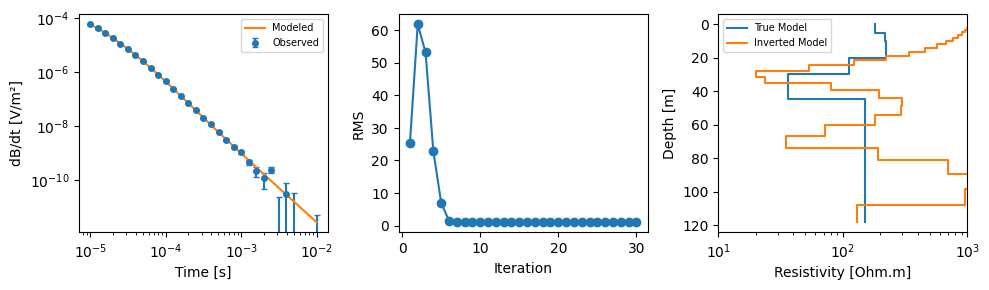

In [ ]:
fig, axs = plt.subplots(1, 3, figsize=(10, 3))

axs[0].errorbar(times, -obs_data, yerr=noise_std, fmt='o', markersize=4, capsize=2, label='Observed')
axs[0].loglog(times, mod_data, '-', label='Modeled', markersize=4)
axs[0].set_xlabel('Time [s]')
axs[0].set_ylabel('dB/dt [V/m²]')
axs[0].legend(fontsize=7)

axs[1].plot(range(1, len(iter_rms_list) + 1), iter_rms_list, 'o-')
axs[1].set_xlabel('Iteration')
axs[1].set_ylabel('RMS')

depths0 = np.cumsum(np.concatenate(([0], thicknesses0[:-1])))
axs[2].step(np.r_[rho0, rho0[-1]], np.r_[depths0, depths[-1]+10], where='pre', label='True Model')
depths = np.cumsum(np.concatenate(([0], thicknesses[:-1])))
axs[2].step(np.r_[best_rho, best_rho[-1]], np.r_[depths, depths[-1]+10], where='pre', label='Inverted Model')

axs[2].invert_yaxis()
axs[2].set_xlabel('Resistivity [Ohm.m]')
axs[2].set_ylabel('Depth [m]')
axs[2].set_xscale('log')
axs[2].legend(fontsize=7)
axs[2].set_xlim(10, 1000)

fig.tight_layout()